# Customer Churn Analysis and Sales Insights Using Python

# Step-1  For importing required liabraries

In [1]:

import pandas as pd
import numpy as Np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings  
warnings.filterwarnings("ignore") #To avoid unrequired warnings(minor)

# Step-2 To load the Ecommerce dataset

In [2]:

df = pd.read_csv("ecommerce_customer_data_large.csv")
    

# Step-3 Inspecting Data

In [3]:

df.head() # showing top 5 rows including header



,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [4]:

df.tail()



,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
249995,33807,2023-01-24 12:32:18,Home,436,1,3664,Cash,63,0.0,Gabriel Williams,63,Male,0
249996,20455,2021-06-04 05:45:25,Electronics,233,1,4374,Credit Card,66,1.0,Barry Foster,66,Female,0
249997,28055,2022-11-10 17:11:57,Electronics,441,5,5296,Cash,63,NaN,Lisa Johnson,63,Female,0
249998,15023,2021-06-27 14:42:12,Electronics,44,2,2517,Cash,64,1.0,Melissa Fernandez,64,Male,0
249999,4148,2020-09-07 05:12:19,Home,307,5,3634,Cash,32,0.0,Angela Norton,32,Male,0


In [25]:

df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            250000 non-null  int64         
 1   Purchase Date          250000 non-null  datetime64[ns]
 2   Product Category       250000 non-null  object        
 3   Product Price          250000 non-null  int64         
 4   Quantity               250000 non-null  int64         
 5   Total Purchase Amount  250000 non-null  int64         
 6   Payment Method         250000 non-null  object        
 7   Returns                202618 non-null  float64       
 8   Customer Name          250000 non-null  object        
 9   Age                    250000 non-null  int64         
 10  Gender                 250000 non-null  object        
 11  Churn                  250000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(6), 

In [19]:

df.shape 



(250000, 12)

In [7]:
df.describe()


,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


In [8]:
df.duplicated().sum()
# duplicate counts duplictaes values in the dataset and sum provides the total

np.int64(0)

In [9]:
df.isnull().sum()
# is null detect null value and sum it count it and provide the total

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

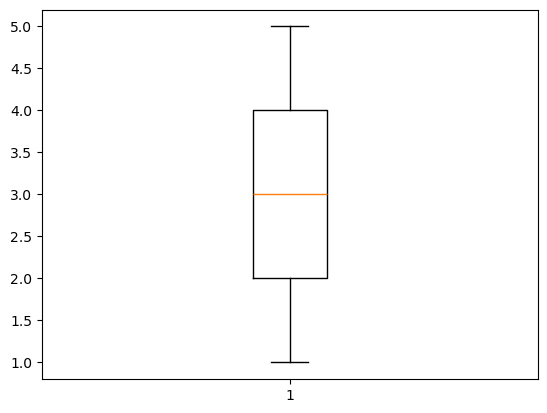

In [10]:
#check outliers in all numerical column
plt.boxplot(df["Quantity"]);

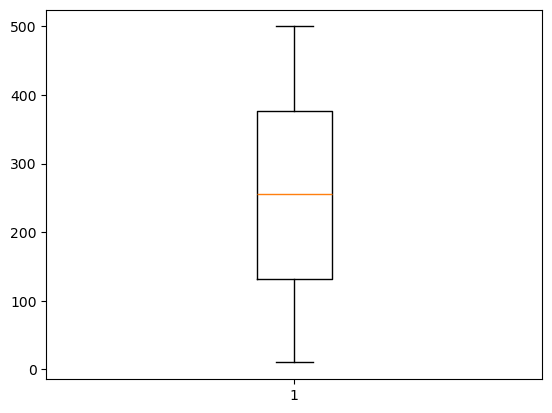

In [13]:
plt.boxplot(df["Product Price"]);

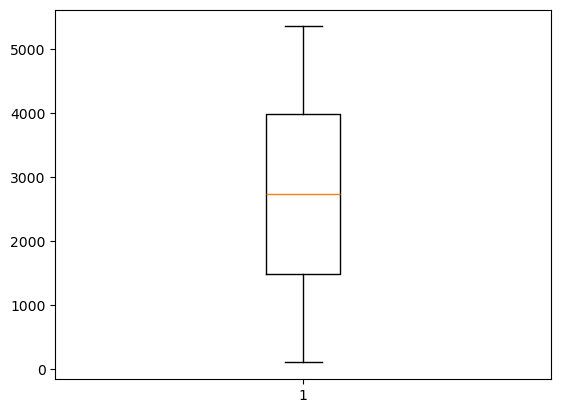

In [12]:
plt.boxplot(df["Total Purchase Amount"]);

# step-4  Data cleaning

In [14]:
df["Customer ID"].dtype

dtype('int64')

In [9]:
# df["Customer ID"]=df["Customer ID"].astype(str) # converting int to str


In [15]:
df["Purchase Date"].dtype


dtype('O')

In [16]:
df["Purchase Date"]=pd.to_datetime(df["Purchase Date"]) #converting string to date


# filling missing values

In [21]:
df.isnull().sum()/df.shape[0]*100 

Customer ID               0.0000
Purchase Date             0.0000
Product Category          0.0000
Product Price             0.0000
Quantity                  0.0000
Total Purchase Amount     0.0000
Payment Method            0.0000
Returns                  18.9528
Customer Name             0.0000
Age                       0.0000
Gender                    0.0000
Churn                     0.0000
dtype: float64

In [20]:
df[df["Returns"].isnull()]

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Returns,Customer Name,Age,Gender,Churn
6,13738,2023-07-25 05:17:24,Electronics,205,1,2773,Credit Card,NaN,Lauren Johnson,27,Female,0
8,13738,2021-12-21 03:29:05,Home,12,2,2175,Cash,NaN,Lauren Johnson,27,Female,0
10,33969,2023-02-28 19:58:23,Clothing,410,3,5018,Credit Card,NaN,Carol Allen,27,Male,0
21,42650,2022-01-26 12:50:30,Electronics,105,2,3721,Credit Card,NaN,Curtis Smith,20,Female,0
26,42650,2020-05-24 06:45:48,Electronics,307,3,973,PayPal,NaN,Curtis Smith,20,Female,0
...,...,...,...,...,...,...,...,...,...,...,...,...
249985,1887,2023-03-31 07:16:20,Clothing,500,3,3268,PayPal,NaN,Christina Alvarado,30,Female,0
249986,20346,2021-12-15 01:35:32,Books,436,1,1265,Cash,NaN,Justin Ross,32,Female,0
249988,31150,2022-03-25 11:15:14,Clothing,101,5,2387,Credit Card,NaN,Jennifer Mason,26,Male,0
249989,26482,2023-04-06 00:42:13,Electronics,467,5,3569,Credit Card,NaN,Linda Hill,33,Male,0


In [22]:
df["Returns"].mode()

0    1.0
Name: Returns, dtype: float64

In [23]:
df["Returns"].mean()

np.float64(0.500824211077002)

In [26]:

df["Returns"]= df["Returns"].fillna(df["Returns"].mode()[0]) # filling nan with mode

In [17]:
# drop the extra age column
df.drop("Customer Age",axis=1 ,inplace = True)  

In [27]:
#recheck afer changes

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            250000 non-null  int64         
 1   Purchase Date          250000 non-null  datetime64[ns]
 2   Product Category       250000 non-null  object        
 3   Product Price          250000 non-null  int64         
 4   Quantity               250000 non-null  int64         
 5   Total Purchase Amount  250000 non-null  int64         
 6   Payment Method         250000 non-null  object        
 7   Returns                250000 non-null  float64       
 8   Customer Name          250000 non-null  object        
 9   Age                    250000 non-null  int64         
 10  Gender                 250000 non-null  object        
 11  Churn                  250000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(6), 

In [28]:
# Step-5  EDA 

# segeregating numerical and categorical column
Numerical_Cols = df.select_dtypes(include=['int64','float64'])
Category_Cols = df.select_dtypes(include=['object'])
print(Numerical_Cols)
print(Category_Cols);


        Customer ID  Product Price  Quantity  Total Purchase Amount  Returns  \
0             44605            177         1                   2427      1.0   
1             44605            174         3                   2448      1.0   
2             44605            413         1                   2345      1.0   
3             44605            396         3                    937      0.0   
4             44605            259         4                   2598      1.0   
...             ...            ...       ...                    ...      ...   
249995        33807            436         1                   3664      0.0   
249996        20455            233         1                   4374      1.0   
249997        28055            441         5                   5296      1.0   
249998        15023             44         2                   2517      1.0   
249999         4148            307         5                   3634      0.0   

        Age  Churn  
0        31      0

In [36]:
#Step-6 Time period Analysis
df["Month"]=df["Purchase Date"].dt.month_name()
df["Month"].value_counts()


Month
August       23160
July         23033
May          22994
January      22882
March        22838
April        22138
June         22132
February     20881
September    18967
December     17234
October      17051
November     16690
Name: count, dtype: int64

In [37]:
df["Year"]=df["Purchase Date"].dt.year
df["Year"].value_counts()

Year
2020    67775
2022    67585
2021    67403
2023    47237
Name: count, dtype: int64

# Top 10 High-Value Customers

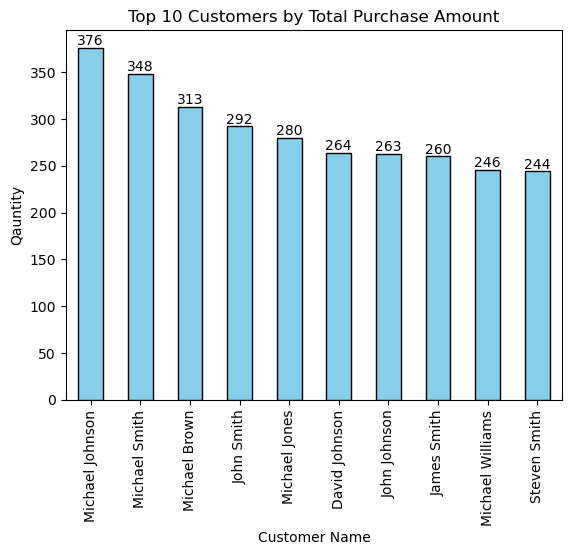

In [39]:
# Top 10 Customers by Total Purchase Amount
Top_Customers=(df.groupby("Customer Name")["Quantity"].sum().sort_values(ascending=False).head(10))
ax= Top_Customers.plot(kind="bar",color="SkyBlue",edgecolor="Black")
plt.title("Top 10 Customers by Total Purchase Amount")
plt.ylabel("Qauntity")
plt.xlabel("Customer Name")
for c in ax.containers:        
 ax.bar_label(c,fmt="%.0f")
plt.show()

# Revenue by Product Category

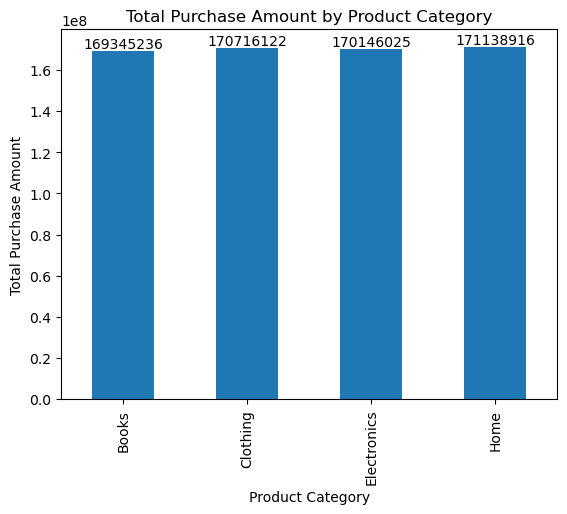

In [41]:
# 1.Total Purchase amount by Product Category
Category_Sales=df.groupby("Product Category")["Total Purchase Amount"].sum()
ax= Category_Sales.plot(kind="bar")
plt.title("Total Purchase Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Purchase Amount")
for c in ax.containers:
  ax.bar_label(c,fmt="%.0f")
plt.show()                    
                    

# Quarter-wise Sales Trend

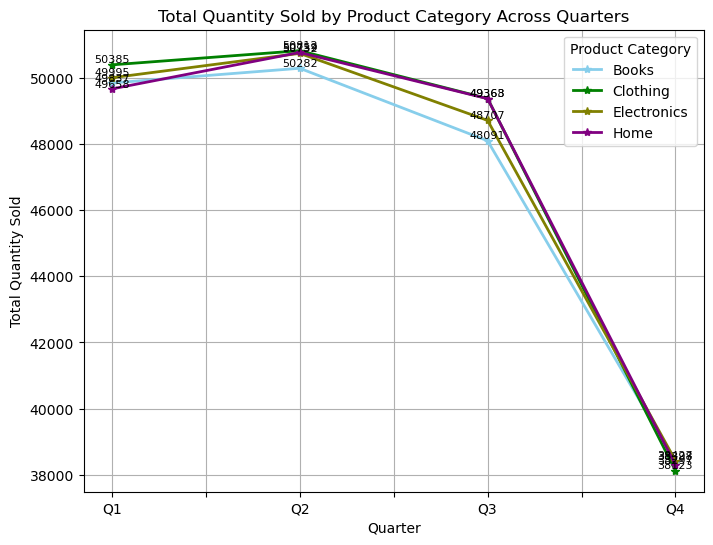

Product Category  Books  Clothing  Electronics   Home
Quarter                                              
Q1                49837     50385        49995  49658
Q2                50282     50812        50732  50759
Q3                48091     49368        48707  49363
Q4                38398     38123        38427  38297


In [87]:
# Quarter-wise Quantity Sold by Product Category
df["Quarter"]="Q"+ df["Purchase Date"].dt.quarter.astype(str)
Quarterly_Sales=df.groupby(["Quarter","Product Category"])["Quantity"].sum().unstack()
ax=Quarterly_Sales.plot(kind="line",marker="*",figsize=(8,6),linewidth=2, color=["SkyBlue","Green","Olive","Purple"])
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.text(x, y, int(y), ha="center", va="bottom", fontsize=8)

plt.title("Total Quantity Sold by Product Category Across Quarters")
plt.xlabel("Quarter")
plt.ylabel("Total Quantity Sold")
plt.grid(True)
plt.legend(title="Product Category")

plt.show()
print(Quarterly_Sales)

# Returns Analysis

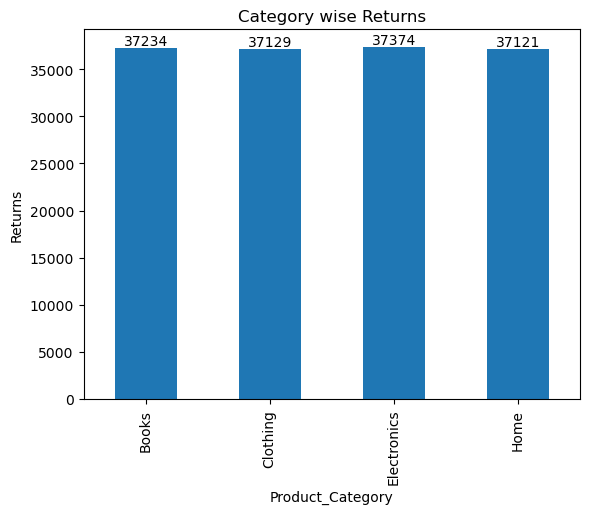

In [47]:
ax=Return_Category.plot(kind="bar")
plt.title("Category wise Returns")
plt.xlabel("Product_Category")
plt.ylabel("Returns")
for c in ax.containers:
    ax.bar_label(c,fmt="%.0f")
plt.show()


# Customer Churn by Gender and Product Category

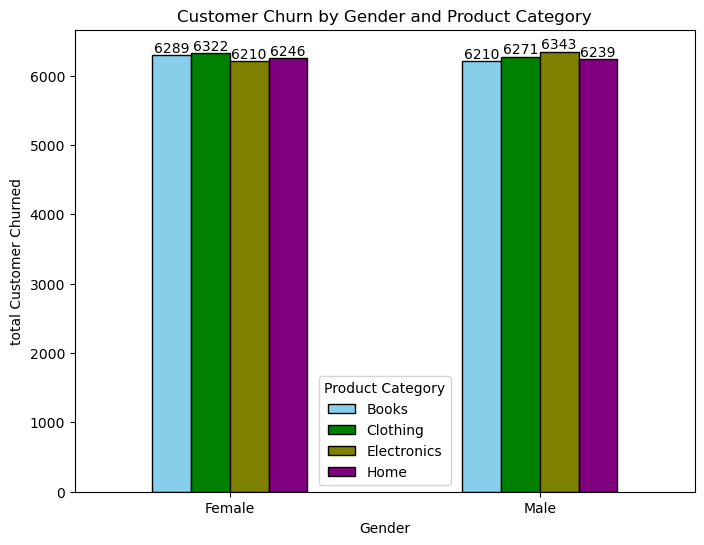

In [49]:
# Customer Churn by Gender and Product Category
Churn_Analysis=df.groupby(["Gender","Product Category"])["Churn"].sum().unstack()
ax=Churn_Analysis.plot(kind="bar",figsize=(8,6),color=["SkyBlue","Green","olive","purple"],edgecolor="black")
for i in ax.containers:
    ax.bar_label(i)
plt.title("Customer Churn by Gender and Product Category")
plt.xlabel("Gender")
plt.ylabel("total Customer Churned")
plt.xticks(rotation=0)
plt.legend(title="Product Category");

# Correlation Analysis

<Axes: >

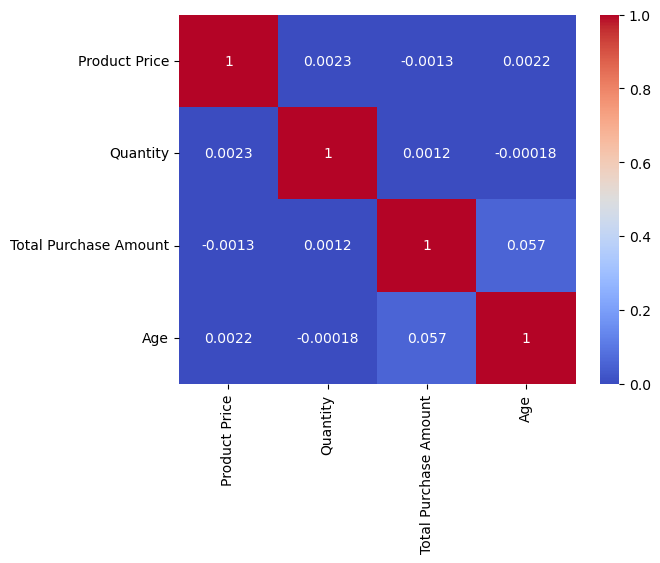

In [45]:

corr = df[["Product Price","Quantity","Total Purchase Amount","Age"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

# Returns Distribution

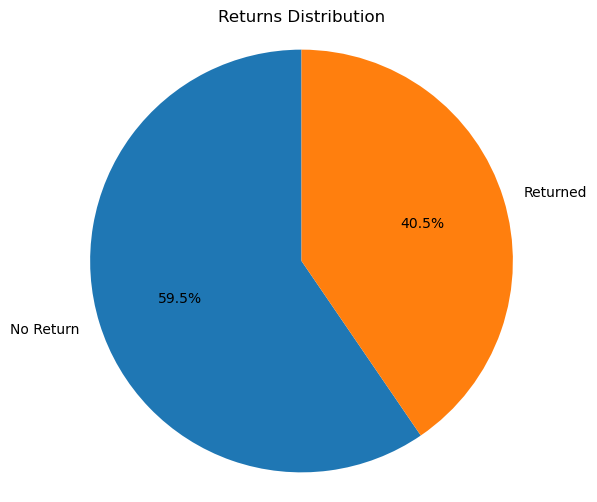

In [48]:
return_counts = df['Returns'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(return_counts,
        labels=['No Return', 'Returned'],
        autopct='%1.1f%%',
        startangle=90)

plt.title("Returns Distribution")
plt.axis('equal')
plt.show()